# 02 — Dataset Exploration

Sanity-checks both datasets before training: `dataset.npz` (hand, 63-dim)
and `pose_dataset.npz` (arm, 99-dim).


## Hand dataset (`dataset.npz`)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os

hand = np.load('../dataset.npz')
Xh, yh = hand['X'], hand['y']
print(f'X: {Xh.shape}  y: {yh.shape}')
print(f'NaN in X: {np.isnan(Xh).sum()}   Inf in X: {np.isinf(Xh).sum()}')
print(f'min={Xh.min():.4f}  max={Xh.max():.4f}  mean={Xh.mean():.4f}  std={Xh.std():.4f}')


X: (936, 30, 63)  y: (936, 63)
NaN in X: 0   Inf in X: 0
min=-58.0325  max=91.9153  mean=0.3994  std=2.5453


/home/user_02/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


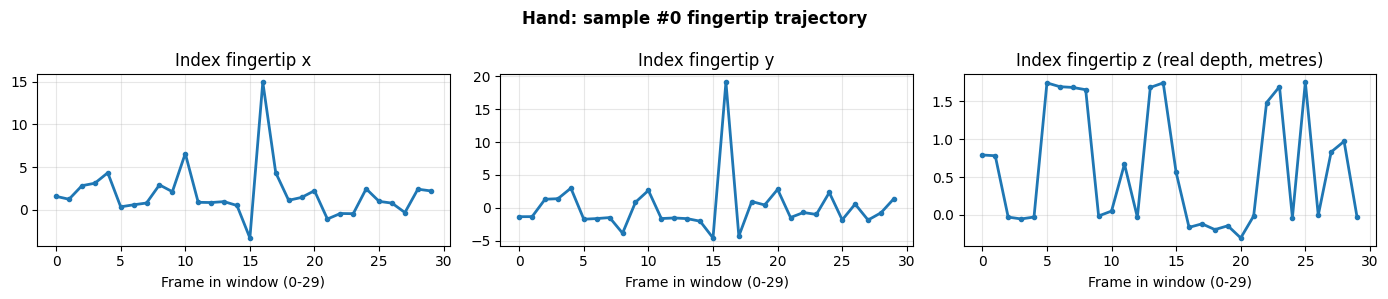

In [2]:
FINGERTIP_IDX = 8   # index fingertip -- moves relative to the wrist
sample = Xh[0]
tip_xyz = sample[:, FINGERTIP_IDX*3 : FINGERTIP_IDX*3 + 3]

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for i, (ax, label) in enumerate(zip(axes, ['x', 'y', 'z (real depth, metres)'])):
    ax.plot(tip_xyz[:, i], linewidth=2, marker='o', markersize=3)
    ax.set_title(f'Index fingertip {label}')
    ax.set_xlabel('Frame in window (0-29)')
    ax.grid(alpha=0.3)
plt.suptitle('Hand: sample #0 fingertip trajectory', fontweight='bold')
plt.tight_layout()
plt.show()


## Pose dataset (`pose_dataset.npz`)

In [3]:
pose = np.load('../pose_dataset.npz')
Xp, yp = pose['X'], pose['y']
print(f'X: {Xp.shape}  y: {yp.shape}')
print(f'NaN in X: {np.isnan(Xp).sum()}   Inf in X: {np.isinf(Xp).sum()}')
print(f'min={Xp.min():.4f}  max={Xp.max():.4f}  mean={Xp.mean():.4f}  std={Xp.std():.4f}')


X: (3139, 30, 99)  y: (3139, 99)
NaN in X: 0   Inf in X: 0
min=-104.1967  max=671.9052  mean=1.0175  std=6.1442


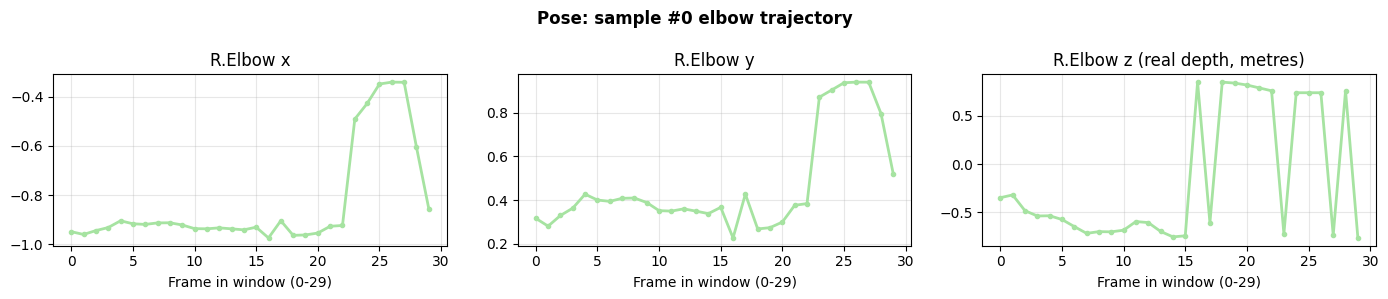

In [4]:
ELBOW_IDX = 14   # R.Elbow
sample = Xp[0]
elbow_xyz = sample[:, ELBOW_IDX*3 : ELBOW_IDX*3 + 3]

fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for i, (ax, label) in enumerate(zip(axes, ['x', 'y', 'z (real depth, metres)'])):
    ax.plot(elbow_xyz[:, i], linewidth=2, marker='o', markersize=3, color='#a6e3a1')
    ax.set_title(f'R.Elbow {label}')
    ax.set_xlabel('Frame in window (0-29)')
    ax.grid(alpha=0.3)
plt.suptitle('Pose: sample #0 elbow trajectory', fontweight='bold')
plt.tight_layout()
plt.show()


## Summary

- [ ] Both `X.shape` match `(N, 30, 63)` / `(N, 30, 99)`
- [ ] No NaN/Inf
- [ ] Both trajectory plots look like real motion, not noise or a flat line

**Next:** `03_lstm_training.ipynb`
